In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import platform

pd.set_option('display.float_format',"{:.2f}".format)

# OS에 따라 다른 폰트 지정
if platform.system() == 'Darwin':   # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':  # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:  # Linux (예: Colab, Ubuntu)
    plt.rcParams['font.family'] = 'NanumGothic'

In [45]:
folder_path = "h&m dataset" #########--------------------- 자기 경로로 수정하기!
article_df = pd.read_csv(folder_path+"/articles_hm.csv")
customer_df = pd.read_csv(folder_path+"/customer_hm.csv")
transaction_df = pd.read_csv(folder_path+"/transactions_hm.csv")

In [46]:
whole_df = pd.merge(
    pd.merge(
        transaction_df,
        customer_df,
        on = 'customer_id'
    ),
    article_df,
    on ='article_id'
)
df = whole_df[['t_dat','customer_id','Active','age','section_no','section_name','index_group_no','index_group_name','product_type_no','product_type_name','price']].copy()
df['price'] = df['price']*1000

In [47]:
price_data = df['price']

In [48]:
df.head().T

,0,1,2,3,4
t_dat,2019-11-05,2019-05-22,2019-05-10,2019-08-26,2019-08-10
customer_id,3e2b60b679e62fb49516105b975560082922011dd752ec...,89647ac2274f54c770aaa4b326e0eea09610c252381f37...,2ebe392150feb60ca89caa8eff6c08b7ef1138cd6fdc71...,7b3205de4ca17a339624eb5e3086698e9984eba6b47c56...,3b77905de8b32045f08cedb79200cdfa477e9562429a39...
Active,1,0,1,0,0
age,51,28,37,19,35
section_no,53,6,21,65,26
section_name,Divided Collection,Womens Casual,Contemporary Casual,Womens Big accessories,Men Underwear
index_group_no,2,1,3,1,3
index_group_name,Divided,Ladieswear,Menswear,Ladieswear,Menswear
product_type_no,252,254,274,66,302
product_type_name,Sweater,Top,Shorts,Bag,Socks


### 가설 검정 순서
1. 가설 설정
    - 대립가설 : 밝히고자 하는 가설
    - 귀무가설  : 대립가설의 반대  / 보통 차이가 없다 같은 내용을 담음.
2. 검정 방법 선택
    - t-검정 전제 조건을 확인 
        - 정규성 : Q-Q plot, K-S test 
        - 등분산성 : Levene 
3. 유의 수준 결정
4. 검정 통계량 / p-value 계산 
5. 결과 해석/ 결론
    - p-value < 유의수준 : 귀무가설 기각
    - p-value >= 유의수준 : 귀무가설 채택

## 1. 단일 표본 검증
- 전제 조건 : 정규성
    - 만족하면, 단일 표본 t-검정
    - 불만족하면, 윌콕슨 부호순위 검정

대립가설 : 드레스를 구입하는 고객들의 평균 가격은 75보다 높다. <br>
귀무가설 : 드레스를 구입하는 고객들의 평균 가격은 75이하이다. 

In [49]:
# 전체 거래내역에서 상품 타입이 드레스인 것만 추출
dress_df = df.loc[df['product_type_name']=='Dress']
# 드레스 거래내역에서 고객별로 평균 가격 구하기
cust_dress_price = dress_df.groupby('customer_id')['price'].mean()

In [50]:
cust_dress_price

customer_id
0000f1c71aafe5963c3d195cf273f7bfd50bbf17761c9199e53dbb81641becd7    53.89
000197360fe727d2cc0887073db9062bf37a8949a95c4a63db58661d94d2cb06   118.63
0001d44dbe7f6c4b35200abdb052c77a87596fe1bdcc37e011580a479e80aa94    48.57
00023e3dd8618bc63ccad995a5ac62e21177338d642d66b42e0038c6b10f655a    28.80
00058c11019467570a6918669b768392f7c9277b7ae4d853bab9cd25f1eae6b4    22.02
                                                                    ...  
c88a25760a67edb28e28c0770443531d947e765a8d653b675ffce9c15b69103f    33.90
c88c0bbdc2fb0b9c7f2aee3ab2241519ec841cc2ed69afdb43cc9ce82b4f1b11    19.47
c88e0d9b0f9a3d2687cdb6030732bc96f6a4b5fc9c62a8b321272b4adc1baefe    23.71
c88e5978f62448cecdb549b80f8c0d6fe940a81bd0a3c8696bdcd30f6c691b28    25.41
c88f5971612e659a4e90d6f08d9c29bdf1e4268fcf52d56ff8c53e2c24157209    16.39
Name: price, Length: 63562, dtype: float64

/Users/yoonseokim/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


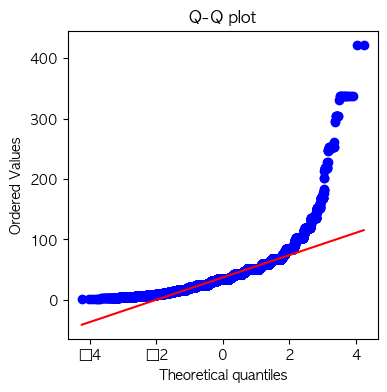

In [51]:
# 정규성 검정 1. Q-Q plot

plt.figure(figsize=(4,4))
stats.probplot(cust_dress_price, plot=plt)
plt.title("Q-Q plot")
plt.show()

In [52]:
# 정규성 검정 2-1. Kolmogorov - Sminov

# 표본 평균
sample_mean = np.mean(cust_dress_price)
# 표본 표준편차
s = np.std(cust_dress_price, ddof=1)

stat, p = stats.kstest(cust_dress_price, 'norm', args=(sample_mean, s))

print(stat, p)

# 정규성 검정 2-2. Shapiro-Wilk

shapiro_stat, shapiro_p = stats.shapiro(cust_dress_price) 

print(shapiro_stat, shapiro_p) # 정규성 기각 --> 윌콕슨 부호순위검정

0.13629432021202031 0.0
0.8329231280847755 4.4588755653860374e-116


/Users/yoonseokim/Library/Python/3.9/lib/python/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 63562.
  res = hypotest_fun_out(*samples, **kwds)


귀무가설 : 정규성을 만족한다 <br>
대립가설 : 정규성을 만족하지 않는다

검정방법 : 윌콕슨 부호순위검정

유의수준 : 0.05로 결정

In [53]:
standard = 75

w_stat, w_p = stats.wilcoxon(cust_dress_price - standard, alternative="greater", zero_method="wilcox")
w_stat, w_p # 귀무가설 채택 --> 75 이하이다

(np.float64(33337671.5), np.float64(1.0))

결론 : p-value가 매우 크므로 귀무가설이 채택 -> 드레스를 구매한 고객들의 평균가격은 75이하이다. 

--------------------------

#### 만약, 정규성을 만족했다면? 

In [54]:
# 단일 표본 t-검정 : stats.ttest_1samp

t_stat, p_value = stats.ttest_1samp(cust_dress_price, popmean=standard, alternative="greater") 
# alternative 변수에는 대립가설의 검정 방향이 들어가게 됨.

# 대립가설과 설정되는 변수(alternative)의 예시 
# ---- cust_dress_price > 75 -- alternative : greater
# ---- cust_dress_price < 75 -- alternative : less 
# ---- cust_dress_price != 75 -- alternative : two-sided(양측 검정)

t_stat, p_value

(np.float64(-473.11913984462046), np.float64(1.0))

## 2. 독립 표본 검증
- 서로 다른 두 집단의 평균을 비교
- 정규성과 등분산성을 모두 확인해야 함 

1. 가설 설정하기 
- 대립가설 : Active 고객의 구매횟수가 Inactive 고객의 구매횟수보다 크다 
- 귀무가설 : Active 고객의 구매횟수가 Inactive 고객의 구매횟수보다 작거나 같다.  

In [55]:
# 고객별로 구매횟수 구하기 
customer_cnt_df = df.groupby(['customer_id','Active'])['section_no'].count().reset_index()
customer_cnt_df = customer_cnt_df.rename(columns={'section_no':'cnt'})

In [56]:
active_df = customer_cnt_df.loc[customer_cnt_df['Active']==1]
inactive_df = customer_cnt_df.loc[customer_cnt_df['Active']==0]

In [57]:
active_df.head()

,customer_id,Active,cnt
3,00007d2de826758b65a93dd24ce629ed66842531df6699...,1,7
4,00009d946eec3ea54add5ba56d5210ea898def4b46c685...,1,5
5,0000ae1bbb25e04bdc7e35f718e852adfb3fbb72ef38b3...,1,1
6,0000f1c71aafe5963c3d195cf273f7bfd50bbf17761c91...,1,8
13,0001d44dbe7f6c4b35200abdb052c77a87596fe1bdcc37...,1,20


In [58]:
active_df.shape, inactive_df.shape

((141832, 3), (211728, 3))

In [59]:
# 두 집단 표본의 크기 맞추기 

active_group = active_df.sample(100000, random_state=42)['cnt']
inactive_group = inactive_df.sample(100000, random_state=42)['cnt']

In [60]:
active_group.shape, inactive_group.shape

((100000,), (100000,))

/Users/yoonseokim/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


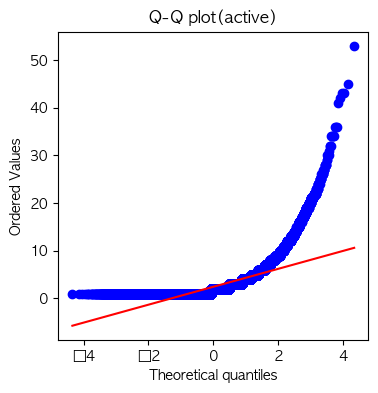

In [61]:
# 정규성 검정 1. Q-Q Plot

plt.figure(figsize=(4,4))
stats.probplot(active_group, plot=plt)
plt.title("Q-Q plot(active)")
plt.show()

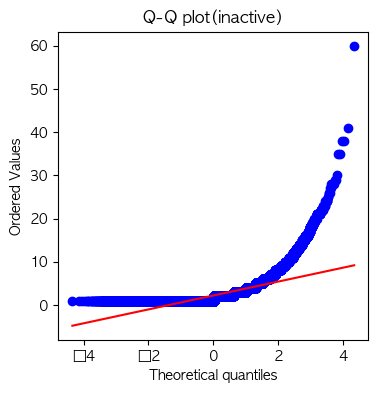

In [62]:
# 정규성 검정 1. Q-Q Plot

plt.figure(figsize=(4,4))
stats.probplot(inactive_group, plot=plt)
plt.title("Q-Q plot(inactive)")
plt.show()

In [63]:
# 정규성 검정 2. Kolmogorov - Sminov

# 표본 평균
sample_mean = np.mean(active_group)
# 표본 표준편차
s = np.std(active_group, ddof=1)

stat, p = stats.kstest(active_group, 'norm', args=(sample_mean, s))

stat, p

(np.float64(0.2706048832805266), np.float64(0.0))

In [64]:
# 정규성 검정 2. Kolmogorov - Sminov

# 표본 평균
sample_mean = np.mean(inactive_group)
# 표본 표준편차
s = np.std(inactive_group, ddof=1)

stat, p = stats.kstest(inactive_group, 'norm', args=(sample_mean, s))

stat, p

(np.float64(0.277740178901084), np.float64(0.0))

In [65]:
# 정규성 검정 2-2. Shapiro-Wilk
stat, p = stats.shapiro(active_group)

stat, p

/Users/yoonseokim/Library/Python/3.9/lib/python/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 100000.
  res = hypotest_fun_out(*samples, **kwds)


(np.float64(0.6287992427895319), np.float64(3.42300689218008e-151))

In [66]:
# 정규성 검정 2-2. Shapiro-Wilk
stat, p = stats.shapiro(inactive_group)

stat, p

(np.float64(0.6167448642713964), np.float64(3.262291786537463e-152))

2. 검정방법 선택 : 맨-휘트니 U-검정
3. 유의수준 : 0.05로 결정

In [67]:
u_stat, u_p = stats.mannwhitneyu(active_group, inactive_group, alternative="greater")
u_stat, u_p

(np.float64(5289659804.0), np.float64(2.859994636357784e-128))

0.0000000000000000000000000000000000000000000000000000000000028599-----

5. 결과해석
- p-value < 유의수준 : 귀무가설 기각 / 대립가설 채택
- active_group의 구매횟수가 inactive_group 횟수보다 많다. (통계적으로 유의미한 차이가 난다. 통계적으로 유의미하게 많다.)

---------------

#### 만약에 정규성을 만족했다면?

In [68]:
# 등분산성 검정 : Levene 검정
stat, p = stats.levene(active_group, inactive_group)
stat, p # 등분산성 기각

(np.float64(384.08990971745595), np.float64(1.9272459831696195e-85))

p-value가 0.05보다 매우 작다 => 대립가설 채택(등분산성을 만족하지 못한다) 

In [69]:
t_stat, p_value = stats.ttest_ind(active_group, inactive_group, equal_var = False, alternative='greater')  ####### 수정: alternative 추가 (원래 들어가야 함!)
# equal_var = True : 등분산 가정 만족 => 독립표본 t-test
# equal_var = False : 등분산 가정 불만족 => Welch t-test

t_stat, p_value

stats.ttest_ind(active_group, inactive_group, equal_var = False, alternative='greater')

TtestResult(statistic=np.float64(24.259979995679092), pvalue=np.float64(4.0388802029422774e-130), df=np.float64(195892.2384108178))

p-value가 0.05보다 매우 작다 -> 귀무가설 기각 -> active group이 inactive group보다 구매횟수가 통계적으로 유믜미하게 많다. 

## 3. 대응 표본 검정 
- 동일한 집단의 전후 평균 비교 ( or 독립적이지 않은 두 쌍의 집단 평균 비교 )

- 프로모션 기간 : 2019-11-01 ~ 2019-11-30
- 프로모션 전 한 달: 2019-10-01 ~ 2019-10-31
- 프로모션 기간과 이전 한 달의 고객의 구매가격 평균을 비교하자 -> 비교대상 : 두 기간 모두 구매한 고객

1. 가설 설정
- 대립가설 :  프로모션 이전 한달보다 프로모션 기간의 평균 구매가격이 더 높다. (price before < price prm)
- 귀무가설 : 프로모션 이전 한 달보다 프로모션 기간의 평균 구매가격이 같거나 낮다. (price before >= price prm)

2. 검정 방법 선택하기
- 후보1. 대응표본 t-test
    - 정규성

In [70]:
df_prm = df.loc[df['t_dat'].between('2019-11-01','2019-11-30')]
df_before = df.loc[df['t_dat'].between('2019-10-01','2019-10-31')]

In [71]:
# 두 번 다 구매한 고객
cust_common = np.intersect1d(df_prm['customer_id'],df_before['customer_id'])
cust_common

array(['00061a04f030bdf3665b09829192ca8c13c4de6dd9ae9d38d0d0b5ce3a1cfc6f',
       '000ab6e1f39b83d936d5855c412d9695f40331c3e9d632d70f6e823ff7aa2b16',
       '001143bec624de9df82bd687babb382e00b0285e2371cc9120de5d42c48f1076',
       ...,
       'c877bdf754fd815d8d471c82c6e3aa44f31cffee8648456859cba33cc1a5a861',
       'c88057ce9c0c9ddba7e125802e3ece063d33377ba1c968ab1cf3ccae8d06b3e3',
       'c88822608b1824dd3968482dad8c98762d54237a96681a1e2bdc77383f84b8bf'],
      dtype=object)

In [72]:
df_prm_cust = df_prm.loc[df_prm['customer_id'].isin(cust_common)]
df_before_cust = df_before.loc[df_before['customer_id'].isin(cust_common)]

In [73]:
prm_cust_price =df_prm_cust.groupby('customer_id')['price'].mean()
before_cust_price = df_before_cust.groupby("customer_id")['price'].mean()

In [74]:
prm_cust_price

customer_id
00061a04f030bdf3665b09829192ca8c13c4de6dd9ae9d38d0d0b5ce3a1cfc6f   59.31
000ab6e1f39b83d936d5855c412d9695f40331c3e9d632d70f6e823ff7aa2b16   41.51
001143bec624de9df82bd687babb382e00b0285e2371cc9120de5d42c48f1076    6.76
00125440be6cd148c3599b9c5a2d55f5838c1b0257d35643038c38a60c691fe8   36.36
00357b192b81fc83261a45be87f5f3d59112db7d117513c1e908e6a7021edc35   40.66
                                                                    ... 
c87594769ce7610413bbc8720f613981badd57c6e247e11d0697343d16e090eb   16.93
c877689ff8e642ad4d6cc342cf4791ddf1c31032e3164a0ef2e47f11c1ff3232   33.88
c877bdf754fd815d8d471c82c6e3aa44f31cffee8648456859cba33cc1a5a861   84.73
c88057ce9c0c9ddba7e125802e3ece063d33377ba1c968ab1cf3ccae8d06b3e3   17.95
c88822608b1824dd3968482dad8c98762d54237a96681a1e2bdc77383f84b8bf   31.42
Name: price, Length: 6193, dtype: float64

In [75]:
before_cust_price

customer_id
00061a04f030bdf3665b09829192ca8c13c4de6dd9ae9d38d0d0b5ce3a1cfc6f   30.49
000ab6e1f39b83d936d5855c412d9695f40331c3e9d632d70f6e823ff7aa2b16   24.71
001143bec624de9df82bd687babb382e00b0285e2371cc9120de5d42c48f1076    6.76
00125440be6cd148c3599b9c5a2d55f5838c1b0257d35643038c38a60c691fe8   28.49
00357b192b81fc83261a45be87f5f3d59112db7d117513c1e908e6a7021edc35   32.19
                                                                    ... 
c87594769ce7610413bbc8720f613981badd57c6e247e11d0697343d16e090eb    8.46
c877689ff8e642ad4d6cc342cf4791ddf1c31032e3164a0ef2e47f11c1ff3232   29.64
c877bdf754fd815d8d471c82c6e3aa44f31cffee8648456859cba33cc1a5a861   11.71
c88057ce9c0c9ddba7e125802e3ece063d33377ba1c968ab1cf3ccae8d06b3e3   15.24
c88822608b1824dd3968482dad8c98762d54237a96681a1e2bdc77383f84b8bf   67.78
Name: price, Length: 6193, dtype: float64

In [76]:
diff = prm_cust_price - before_cust_price

/Users/yoonseokim/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


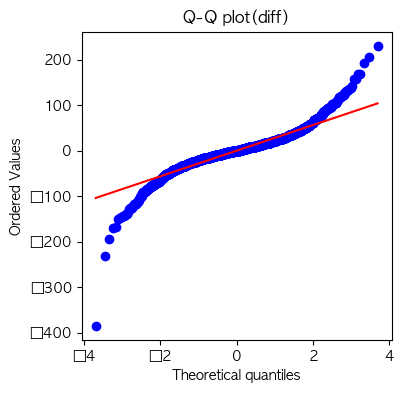

In [77]:
# 정규성 검정 1. Q-Q Plot

plt.figure(figsize=(4,4))
stats.probplot(diff, plot=plt)
plt.title("Q-Q plot(diff)")
plt.show()

In [ ]:
# 정규성 검정 2-1. Kolmogorov - Sminov

# 표본 평균
sample_mean = np.mean(diff)
# 표본 표준편차
s = np.std(diff, ddof=1)

stat, p = stats.kstest(diff, 'norm', args=(sample_mean, s))

stat, p

(np.float64(0.0853751951997257), np.float64(1.0128358467844614e-39))

In [ ]:
# 정규성 검정 2-2. Shapiro-Wilk

stat, p = stats.shapiro(diff) 

stat, p # 정규성 기각

/Users/yoonseokim/Library/Python/3.9/lib/python/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6193.
  res = hypotest_fun_out(*samples, **kwds)


(np.float64(0.9113729471964442), np.float64(5.1789425807007237e-51))

p-value가 매우 작으므로 정규성 가정을 불만족한다. 


2. 검정방법 : 윌콕슨 부호순위검정

In [ ]:
w_stat, w_p = stats.wilcoxon(diff, alternative="greater", zero_method="wilcox")
w_stat, w_p # 귀무가설 채택 --> diff <= 0

(np.float64(9081409.0), np.float64(0.19319600736570902))

귀무가설 채택 => 프로모션 이전 한 달보다 프르모션 기간의 구매가격이 같거나 낮다. 

---------------------

#### 만약 정규성을 만족했다면?

In [80]:
t_stat, p_value = stats.ttest_rel(prm_cust_price, before_cust_price, alternative="greater")
t_stat, p_value

(np.float64(0.47081605383325303), np.float64(0.31889434198093036))